**Análise e Pré Processamento de dados**

 - "Arrumar" / "Preencher" o dataset
 - Retirar dados não utilizáveis
 - Tirar primeiras impressões
 - Tratar dados "errados"

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
dataset = sns.load_dataset('titanic')
df = pd.DataFrame(data=dataset)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Tratando dados nulos**

*O que podemos fazer com dados nulos?* 

1 - Substituir os valores por médias ou medianas

2 - Excluir os dados (Colunas ou linhas)

3 - Imputação extradificada

4 - Imputação por regra

In [89]:
#Tratando Dados Nulos de idade

df['age'].isnull().value_counts()

age
False    714
True     177
Name: count, dtype: int64

<Axes: xlabel='pclass', ylabel='age'>

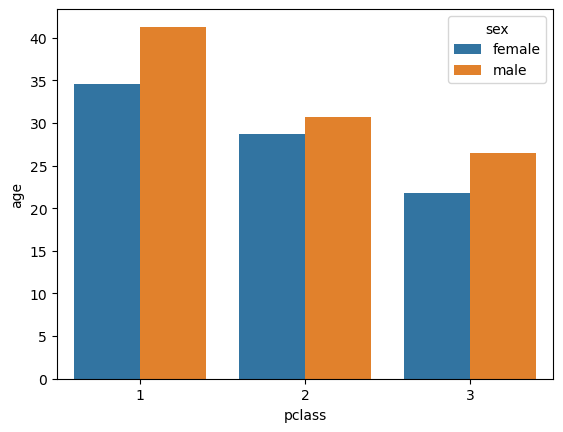

In [90]:

sns.barplot(data=df, x='pclass', y='age', hue='sex', errorbar=None)


In [91]:
#Subtituindo missing values com a mediana de subgrupos, 'class' e 'sex'

df['age'] = df.groupby(['pclass', 'sex'], group_keys=False)['age'].apply(lambda x: x.fillna(x.median()))

In [92]:
df['age'].isnull().value_counts()

age
False    891
Name: count, dtype: int64

In [93]:
#Colunas desnecessárias com dados repetidos

df = df.drop('embark_town', axis=1);
df = df.drop('class', axis=1)

In [94]:
df['embarked'].isnull().sum()

np.int64(2)

In [95]:
df = df.dropna(subset=['embarked'])

**Análises**

*Heatmap de correlação*

 - Olhar a correlação entre variáveis

In [96]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,no,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,yes,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,yes,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,yes,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,no,True


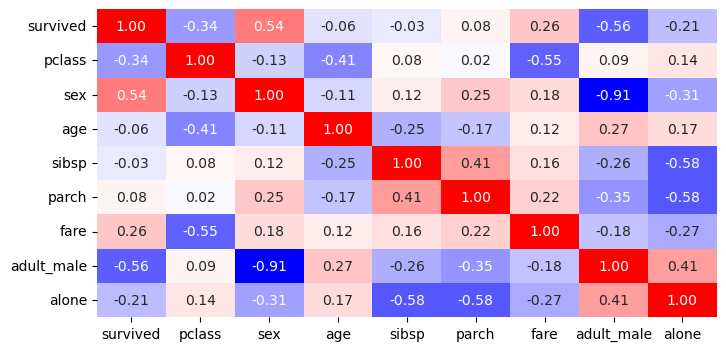

In [97]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8,4));

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='bwr', fmt='.2f', cbar=False);

